# Plotting rate RNN energy landscape

Plotting on a single landscape
- now calculating all distances and plotting
- now changing the single landscape plot to a null plot

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import pickle as pk
from sklearn.decomposition import PCA
import torch

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
# import model
from model import generate_input_stim_xor, eval_tf

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import trajectory_utils as tu
import importlib

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/trajectory/fixed_pt/')
import load_RNN_model as lrm
from run_RNN_search import get_period_pca

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/fixed-point-finder')
from FixedPointFinderTorch import FixedPointFinderTorch as FixedPointFinder
from plot_utils import plot_fps # in fixedpointfinder folder

/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-03-03 21:04:46.469066: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-03 21:04:46.477177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-03 21:04:46.486091: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register facto

Instructions for updating:
non-resource variables are not supported in the long term


## plotting distances for good and bad

### just calculate some performance values (don't run)

(only run once, because saving the file here)

In [ ]:
models_types = ['good_models','bad_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

all_perfs = []
for models_type in models_types:
    print(f'Analyzing {models_type}')
    
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    perfs = np.zeros(len(model_list))
    for i_model in range(len(model_list)):
        model_path = os.path.join(models_dir, model_list[i_model])
        model = scipy.io.loadmat(model_path)
        perf = tu.get_perf(model_path = model_path, 
                           settings=settings, n_trials=100, plot=0)
        perfs[i_model] = perf
    
    all_perfs.append(perfs)
    print(f'Mean performance: {np.mean(perfs)}')
    print(f'Std performance: {np.std(perfs)}')
    print(f'Min performance: {np.min(perfs)}')
    print(f'Max performance: {np.max(perfs)}')

Analyzing good_models
Mean performance: 0.8919512195121951
Std performance: 0.07545696600066149
Min performance: 0.73
Max performance: 1.0
Analyzing bad_models
Mean performance: 0.6269230769230769
Std performance: 0.18900079834526606
Min performance: 0.26
Max performance: 0.96


In [ ]:
# save all_perfs
for i, models_type in enumerate(models_types):
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    these_perfs = np.array(all_perfs[i])
    np.save(f'{results_dir}ratemodel_delay{settings["delay"]}_perfs.npy', these_perfs)
    print(f'Saved {results_dir}ratemodel_delay{settings["delay"]}_perfs.npy')


Saved /scratch/spikeRNN/models/DMS_OSF/good_models/ratemodel_delay150_perfs.npy
Saved /scratch/spikeRNN/models/DMS_OSF/bad_models/ratemodel_delay150_perfs.npy


### same for distances (don't run)

(only run once, because saving the file here)

In [ ]:
importlib.reload(tu)

models_types = ['good_models','bad_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

all_dists = []
for models_type in models_types:
    print(f'Analyzing {models_type}')
    
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    
    dists = np.zeros(len(model_list))
    for i_model in range(len(model_list)):
        model_path = os.path.join(models_dir, model_list[i_model])
        model = scipy.io.loadmat(model_path)
        _, dist = tu.plot_energy_landscape_over_null(model_list[i_model], settings, 
                                title=f'{models_type}: model {i_model}, perf={perfs[i_model]:.2f}',
                                plot=0)
        dists[i_model] = dist

    all_dists.append(dists)


Analyzing good_models
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Analyzing bad_models
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX
Loading synX


In [ ]:
for i, models_type in enumerate(models_types):
    print(models_type)
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    these_dists = np.array(all_dists[i])
    print(f'Mean dist: {np.mean(these_dists)}')
    print(f'Std dist: {np.std(these_dists)}')
    print(f'Min dist: {np.min(these_dists)}')
    print(f'Max dist: {np.max(these_dists)}')

good_models
Mean dist: 9.223327706655299
Std dist: 4.646204067468727
Min dist: 0.750811552894874
Max dist: 15.870242772323442
bad_models
Mean dist: 10.78680774366225
Std dist: 5.593618067715811
Min dist: 1.7415090555117825
Max dist: 20.226058930276942


In [ ]:
# save all_dists
for i, models_type in enumerate(models_types):
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    these_dists = np.array(all_dists[i])
    np.save(f'{results_dir}ratemodel_delay{settings["delay"]}_dists.npy', these_dists)
    print(f'Saved {results_dir}ratemodel_delay{settings["delay"]}_dists.npy')


Saved /scratch/spikeRNN/models/DMS_OSF/good_models/ratemodel_delay150_dists.npy
Saved /scratch/spikeRNN/models/DMS_OSF/bad_models/ratemodel_delay150_dists.npy


### now plotting

In [2]:
# load all_perfs and all_dists
models_types = ['good_models','bad_models']
models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

all_perfs = []
all_dists = []
for models_type in models_types:
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
#     model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
#     model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
#     model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    these_perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_perfs.npy')
    all_perfs.append(these_perfs)
    these_dists = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_dists.npy')
    all_dists.append(these_dists)


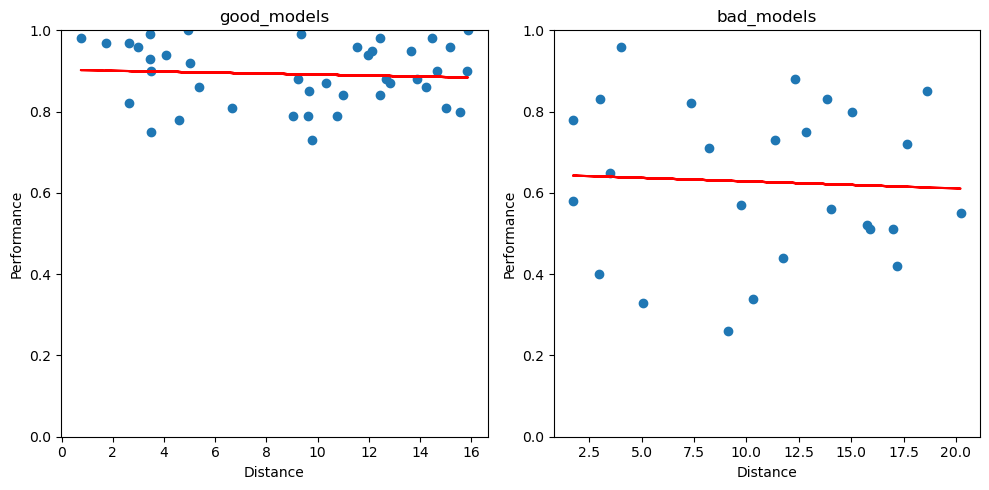

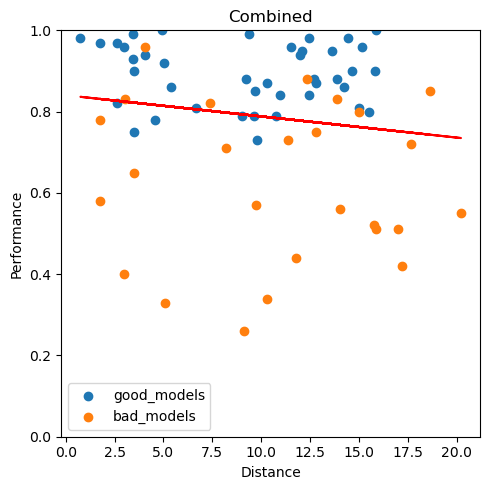

In [15]:
# plot scatter plot with perfs and dists

fig, axs = plt.subplots(1,2, figsize=(10,5))
for i, models_type in enumerate(models_types):
    these_perfs = all_perfs[i]
    these_dists = all_dists[i]

    # calculate best fit line
    m, b = np.polyfit(these_dists, these_perfs, 1)
    axs[i].scatter(these_dists, these_perfs)
    axs[i].plot(these_dists, m*these_dists + b, color='red')
    axs[i].set_title(models_type)
    axs[i].set_xlabel('Distance')
    axs[i].set_ylabel('Performance')
    axs[i].set_ylim([0,1])
plt.tight_layout()
plt.show()

# plot scatter with good and bad combined, and fit line
fig, ax = plt.subplots(1,1, figsize=(5,5))
for i, models_type in enumerate(models_types):
    these_perfs = all_perfs[i]
    these_dists = all_dists[i]
    ax.scatter(these_dists, these_perfs, label=models_type)
# make array with all perfs 1d
all_perfs_flat = np.concatenate(all_perfs)
all_dists_flat = np.concatenate(all_dists)
# calculate best fit line
m, b = np.polyfit(all_dists_flat, all_perfs_flat, 1)
ax.plot(all_dists_flat, m*all_dists_flat + b, color='red')
ax.set_title('Combined')
ax.set_xlabel('Distance')
ax.set_ylabel('Performance')
ax.set_ylim([0,1])
plt.legend()
plt.tight_layout()
plt.show()

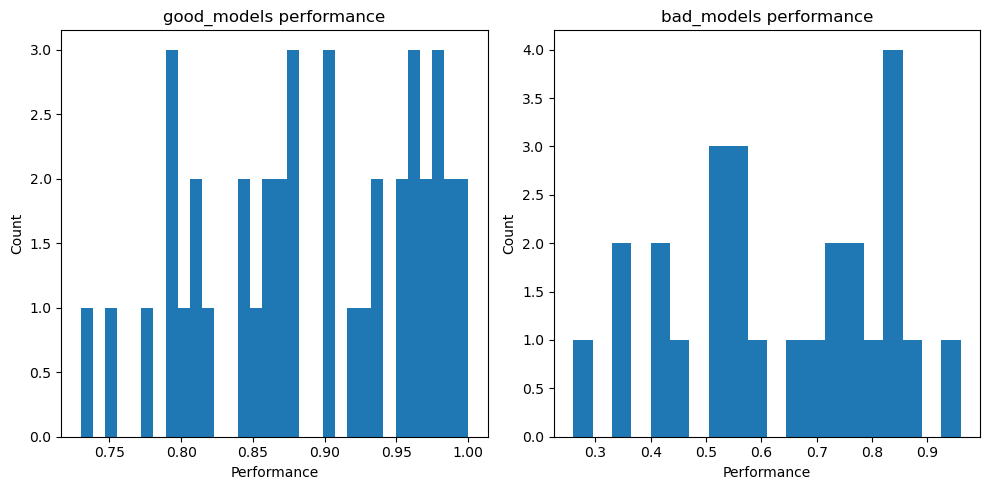

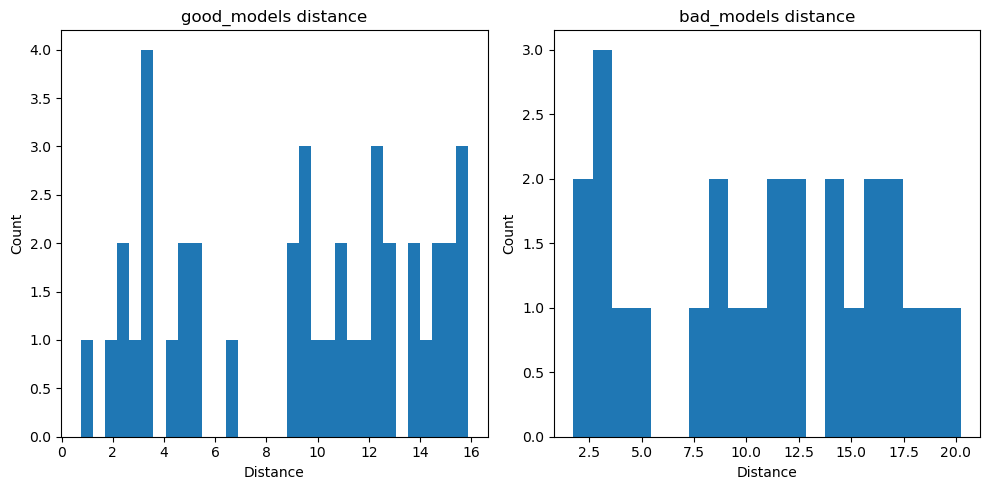

In [18]:
# plot histogram of perfs and dists
fig, axs = plt.subplots(1,2, figsize=(10,5))
for i, models_type in enumerate(models_types):
    these_perfs = all_perfs[i]

    axs[i].hist(these_perfs, bins=int(len(these_perfs)/1.25))
    axs[i].set_title(f'{models_type} performance')
    axs[i].set_xlabel('Performance')
    axs[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,2, figsize=(10,5))
for i, models_type in enumerate(models_types):
    these_dists = all_dists[i]

    axs[i].hist(these_dists, bins=int(len(these_dists)/1.25))
    axs[i].set_title(f'{models_type} distance')
    axs[i].set_xlabel('Distance')
    axs[i].set_ylabel('Count')
plt.tight_layout()

Statistics=443.0, p=0.24949426519199924


/tmp/ipykernel_817336/3492824023.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_dists, labels=models_types)


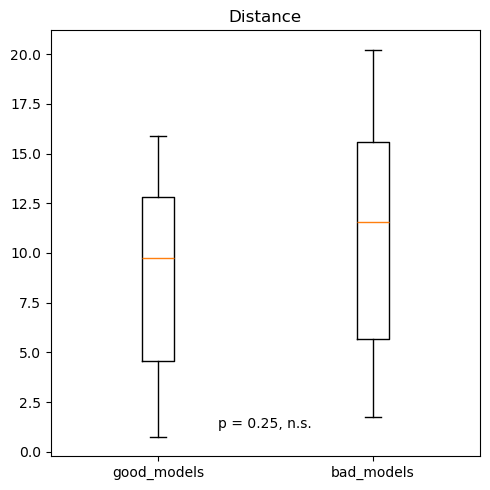

In [21]:
# create boxplot of distances for good and bad models
fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.boxplot(all_dists, labels=models_types)

# calculate mann-whitney u test
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(all_dists[0], all_dists[1])
print(f'Statistics={stat}, p={p}')

if p < 0.05:
    ax.plot([1,2], [1.1,1.1], color='k')
    ax.text(1.5, 1.2, '*', horizontalalignment='center')
else:
    ax.text(1.5, 1.2, f'p = {p:.2f}, n.s.', horizontalalignment='center')

ax.set_title('Distance')
plt.tight_layout()
plt.show()

Statistics=160.0, p=0.1966827640022325


/tmp/ipykernel_833258/3944577474.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_dists_thresh, labels=models_types)


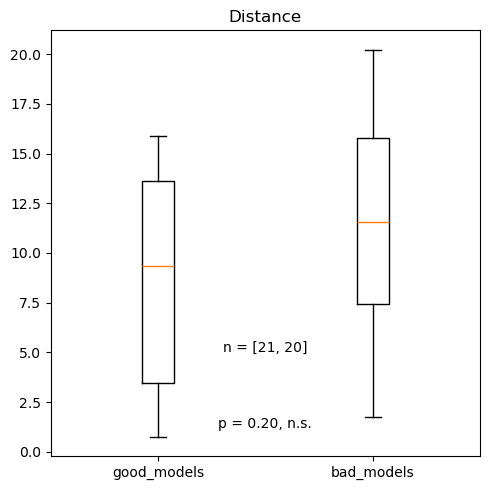

In [6]:
# create boxplot of distances for good and bad models
fig, ax = plt.subplots(1,1, figsize=(5,5))

perf_threshold = [0.9, 0.8]
all_dists_thresh = []
all_dists_thresh.append(all_dists[0][all_perfs[0] >= perf_threshold[0]])
all_dists_thresh.append(all_dists[1][all_perfs[1] <= perf_threshold[1]])

ax.boxplot(all_dists_thresh, labels=models_types)

# calculate mann-whitney u test
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(all_dists_thresh[0], all_dists_thresh[1])
print(f'Statistics={stat}, p={p}')

if p < 0.05:
    ax.plot([1,2], [1.1,1.1], color='k')
    ax.text(1.5, 1.2, '*', horizontalalignment='center')
else:
    ax.text(1.5, 1.2, f'p = {p:.2f}, n.s.', horizontalalignment='center')

# plot n as text
n = [len(all_dists_thresh[0]), len(all_dists_thresh[1])]
ax.text(1.5, 5, f'n = {n}', horizontalalignment='center')


ax.set_title('Distance')
plt.tight_layout()
plt.show()

## Good model

In [2]:
models_type = 'good_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
good_model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

In [ ]:
# delay = 150
importlib.reload(tu)
perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_perfs.npy')
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    tu.plot_energy_landscape_over_combined(good_model_list[i_model], settings, 
                             title=f'{models_type}: model {i_model}, perf={perfs[i_model]:.2f}')
    
    if i_model == 2:
        break



### trying with a stim1 of 0

#### manual stepping through code

In [ ]:
importlib.reload(tu)
for i_model in range(len(good_model_list)):
    RNN_model_file = good_model_list[i_model]
    model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'
    rnn_path = os.path.join(models_dir, RNN_model_file) 
    model_path = os.path.join(models_dir, RNN_model_file)
    model = scipy.io.loadmat(model_path)

    # generate this for one model
    synX, trial_stim_labels = tu.generate_synX(rnn_path, settings, 
                                               stim1s=[0], stim2s = [-1,1],
                                               n_trials=500, save=0)
    
    
    break

In [13]:
save_flag = 'null'
np.save(f'{model_results_dir}delay{settings["delay"]}_synX_{save_flag}.npy', synX)

In [14]:
rnn_data = scipy.io.loadmat(models_dir + RNN_model_file)
# Loading model parameters
taus_gaus = torch.tensor(rnn_data['taus_gaus'])
taus = torch.tensor(rnn_data['taus'][0])
w = torch.tensor(rnn_data['w'])
m = torch.tensor(rnn_data['m'])
w_in = torch.tensor(rnn_data['w_in'])
taus_sig = torch.sigmoid(taus_gaus)*(taus[1] - taus[0]) + taus[0] # Neural time constant
ww = torch.matmul(w, m) # Recurrent weight matrix

xx_trials_null = synX

In [15]:
xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')

Text(0.02, 0.5, 'PC2')

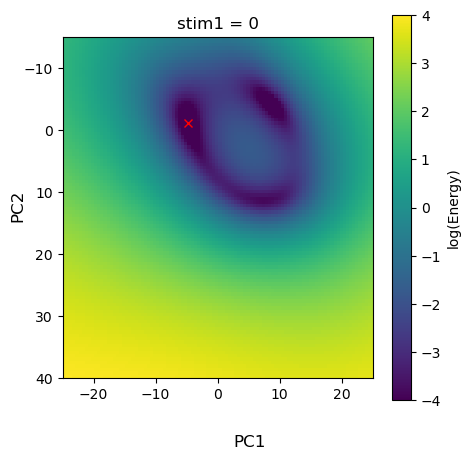

In [12]:
stim1 = 0 

nComponents = 2
pca_period = tu.get_period_pca(xx_trials[trial_stim_labels[:,0] == stim1,:,:],'delay',settings, nComponents)

# PC space grid 
res = 100
xVec_lim=[-25,25]
yVec_lim=[-15,40]

xVec = np.linspace(xVec_lim[0],xVec_lim[1],res)
yVec = np.linspace(yVec_lim[0],yVec_lim[1],res)

fig, axs = plt.subplots(1,1, figsize=(5,5))
u = torch.tensor([0,0], dtype=torch.float32) # current stim is always 0 bc delay
qMatrix = np.zeros((res,res))            
for i in np.arange(res):
    for j in np.arange(res):
        x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
        qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
# Getting minimum energy point    
min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
im = axs.imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=-4, vmax=4)
axs.plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
axs.set_title(f'stim1 = 0')

# divider = make_axes_locatable(axs[-1])
# cax = divider.append_axes("right", size="5%", pad=0.05)

cbar=plt.colorbar(im)#, cax=cax)
cbar.set_label('log(Energy)')

# common axis labels
fig.supxlabel('PC1')
fig.supylabel('PC2')

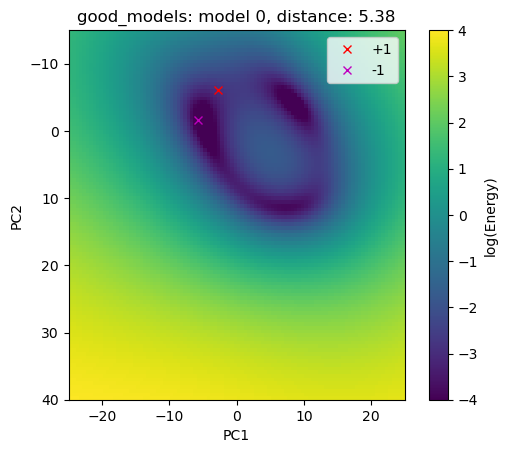

In [17]:
title = f'{models_type}: model {i_model}'

stim_condns = [0, 1, -1]
stim_names = ['null', '+1','-1']
markers = ['rx','mx']

n_minima = len(stim_condns)-1
minima = np.zeros((n_minima,2))
# fig, axs = plt.subplots(1, len(stim_condns),sharey=True, figsize=(10,4))
for plotI, stim1 in enumerate(stim_condns):
    # Creating a 2d grid over PC space to plot different qs
    nComponents = 2
    if stim1 == 0: # get both +1 and -1 trials
        pca_period = tu.get_period_pca(xx_trials_null,'delay',settings, nComponents)
    else:
        pca_period = tu.get_period_pca(xx_trials[trial_stim_labels[:,0] == stim1,:,:],'delay',settings, nComponents)

    # PC space grid 
    res = 100

    xVec = np.linspace(xVec_lim[0],xVec_lim[1],res)
    yVec = np.linspace(yVec_lim[0],yVec_lim[1],res)

    u = torch.tensor([0,0], dtype=torch.float32) # current stim is always 0 bc delay
    qMatrix = np.zeros((res,res))            
    for i in np.arange(res):
        for j in np.arange(res):
            x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
            qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
    # Getting minimum energy point    
    min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
    minima[plotI-1,:] = [xVec[min_idx[0]],yVec[min_idx[1]]]

    if stim1 == 0:
        im = plt.imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=-4, vmax=4)
    else:
        plt.plot(xVec[min_idx[0]],yVec[min_idx[1]],markers[plotI-1], label=f'{stim_names[plotI]}')

dist = np.linalg.norm(minima[0]-minima[1])
    
cbar=plt.colorbar(im)
cbar.set_label('log(Energy)')
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
if len(title) > 0:
    title_dist = f'{title}, distance: {dist:.2f}'
    plt.title(title_dist)
else:
    plt.title(f'Energy landscape for {RNN_model_file[-4]}')
plt.show()

#### now making it a function

Loading synX
Loading synX null


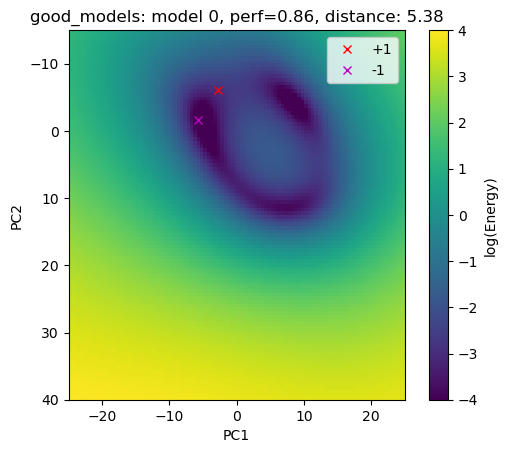

In [5]:
importlib.reload(tu)

perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_perfs.npy')
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    tu.plot_energy_landscape_over_null(good_model_list[i_model], settings, 
                             title=f'{models_type}: model {i_model}, perf={perfs[i_model]:.2f}')
    
    break
    # if i_model == 2:
    #     break


Loading synX
Loading synX null


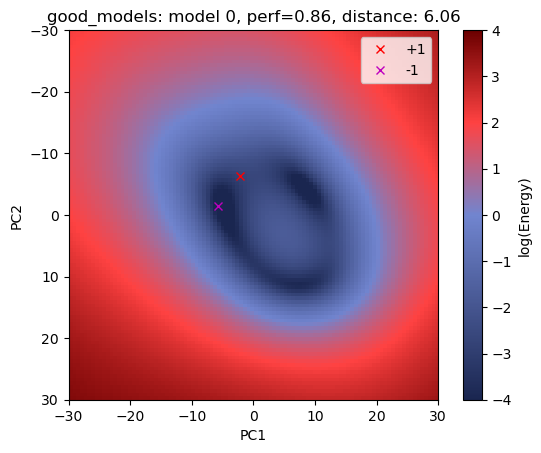

Loading synX
Loading synX null


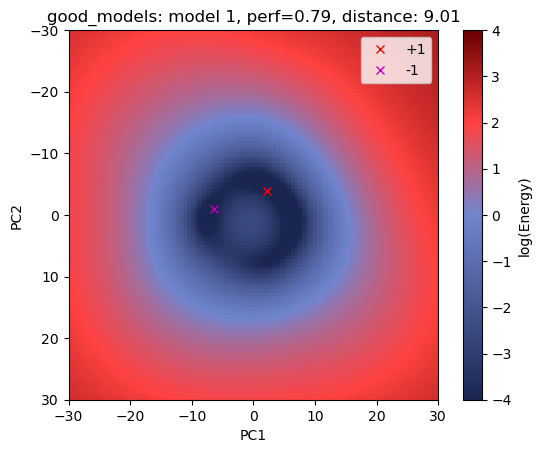

Loading synX
Loading synX null


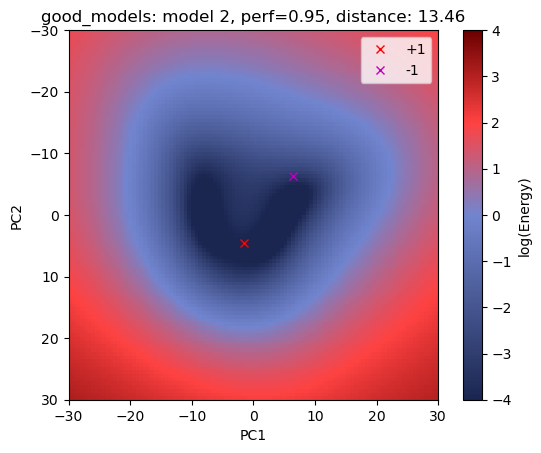

In [4]:
importlib.reload(tu)

perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_perfs.npy')
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    tu.plot_energy_landscape_over_null(good_model_list[i_model], settings, xVec_lim=[-30,30], yVec_lim=[-30,30],
                             title=f'{models_type}: model {i_model}, perf={perfs[i_model]:.2f}')
    
    if i_model == 2:
        break


## Bad model

In [5]:
models_type = 'bad_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [6]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

In [ ]:
# delay = 150
importlib.reload(tu)
perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_perfs.npy')
for i_model in range(len(model_list)):
    model_path = os.path.join(models_dir, model_list[i_model])
    model = scipy.io.loadmat(model_path)
    tu.plot_energy_landscape_over_combined(model_list[i_model], settings, 
                             title=f'{models_type}: model {i_model}, perf={perfs[i_model]:.2f}')
    
    if i_model == 2:
        break



Loading synX
Loading synX null


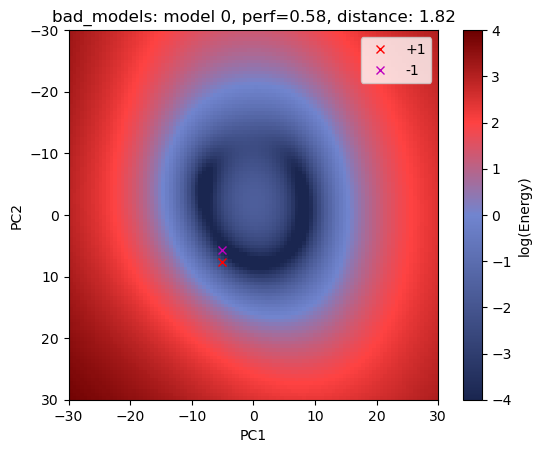

Loading synX
Loading synX null


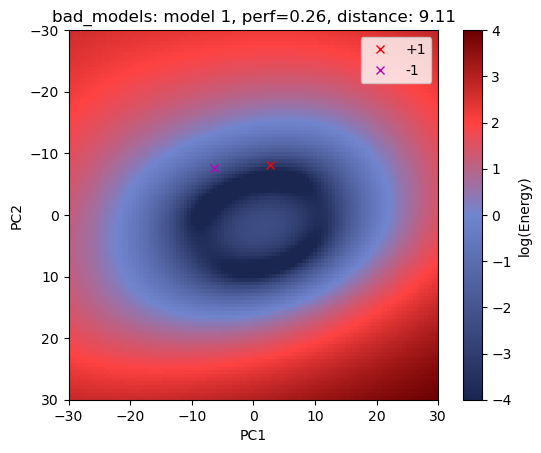

Loading synX
Loading synX null


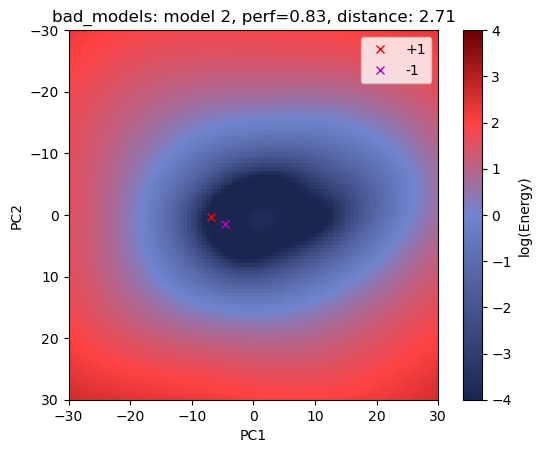

In [6]:
importlib.reload(tu)

perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_perfs.npy')
for i_model in range(len(model_list)):
    model_path = os.path.join(models_dir, model_list[i_model])
    model = scipy.io.loadmat(model_path)
    tu.plot_energy_landscape_over_null(model_list[i_model], settings,  xVec_lim=[-30,30], yVec_lim=[-30,30],
                             title=f'{models_type}: model {i_model}, perf={perfs[i_model]:.2f}')
    
    if i_model == 2:
        break

## Plots for VP&S student research day poster

#### good model

In [2]:
models_type = 'good_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

Loading synX
Loading synX null
/home/nuttidalab/Documents/spikeRNN/results/2025_SRD/good_model_landscape.svg


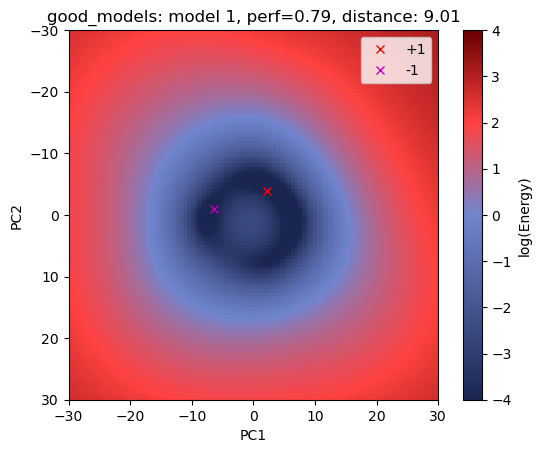

(array([[ 2.12121212, -3.93939394],
        [-6.36363636, -0.90909091]]),
 9.009738634738492)

In [5]:
importlib.reload(tu)

perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_perfs.npy')

i_model = 1

model_path = os.path.join(models_dir, model_list[i_model])
model = scipy.io.loadmat(model_path)
tu.plot_energy_landscape_over_null(model_list[i_model], settings,  xVec_lim=[-30,30], yVec_lim=[-30,30],
                            title=f'{models_type}: model {i_model}, perf={perfs[i_model]:.2f}')


#### bad model

In [6]:
models_type = 'bad_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [7]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

Loading synX
Loading synX null
/home/nuttidalab/Documents/spikeRNN/results/2025_SRD/bad_model_landscape.svg


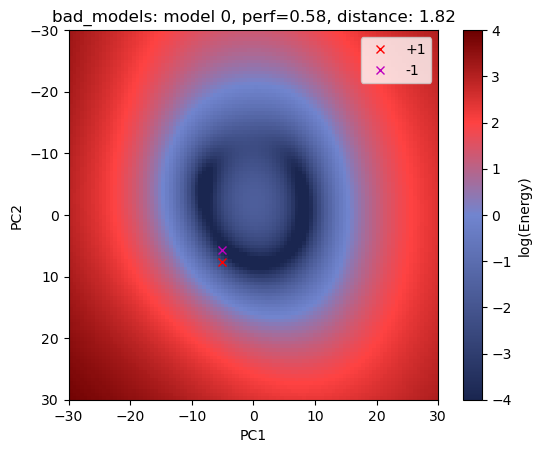

(array([[-5.15151515,  7.57575758],
        [-5.15151515,  5.75757576]]),
 1.8181818181818201)

In [8]:
importlib.reload(tu)

perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_perfs.npy')

i_model = 0

model_path = os.path.join(models_dir, model_list[i_model])
model = scipy.io.loadmat(model_path)
tu.plot_energy_landscape_over_null(model_list[i_model], settings, xVec_lim=[-30,30], yVec_lim=[-30,30],
                            title=f'{models_type}: model {i_model}, perf={perfs[i_model]:.2f}')
